* This project utilizes a Convolutional Neural Network (CNN) to achieve high accuracy on the Indian Traffic Sign Dataset (59 classes).
* Goal: Classify 59 unique Indian traffic signs and map the predicted sign to a driving action (e.g., "APPLY BRAKES").
* Model: LeNet-like CNN architecture.
* Dataset Source: The provided Indian Traffic Sign Dataset (59 classes, 32 X 32 X 3 images).

In [1]:
# Cell 1: Imports and Constants for Indian Traffic Sign Classification (ITSRD)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Confirmed from Kaggle dataset description
NUM_CLASSES = 59 
IMG_SIZE = 32 
 
BASE_DIR = '/kaggle/input/indian-traffic-sign-dataset/'

# Model file name
MODEL_FILE_NAME = 'indian_ts_classifier.h5'

print(f"Project initialized for {NUM_CLASSES} Indian Traffic Sign Classes with {IMG_SIZE}x{IMG_SIZE} image size.")

2025-11-06 12:01:19.669965: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762430479.924809      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762430479.994955      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Project initialized for 59 Indian Traffic Sign Classes with 32x32 image size.


In [2]:
# Cell 2: Load Images from Folders, Split, and Normalize

# --- 2A: Define Image Directory ---
#FINAL FIX: Use the exact, confirmed nested path
train_images_dir = '/kaggle/input/indian-traffic-sign-dataset/Indian-Traffic Sign-Dataset/Images'

# --- Debug Check (Simplified) ---
if not os.path.isdir(train_images_dir):
    # This should never be reached now, but remains as a final safeguard
    print(f" FATAL ERROR: Path verification failed for: {train_images_dir}")
    raise FileNotFoundError("Kaggle path failed even after diagnostics.")
print(f"Loading images from {train_images_dir}...")

# --- 2B: Load Images and Labels (Folder-Based) ---
data = []
labels = []

# Iterate through all items inside the final located image directory
for class_folder_name in os.listdir(train_images_dir):
    
    if not class_folder_name.isdigit():
        continue
        
    class_id = int(class_folder_name)
    path_to_class = os.path.join(train_images_dir, class_folder_name)
    
    if not os.path.isdir(path_to_class):
        continue

    # Process all image files in the class directory
    for img_name in os.listdir(path_to_class):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(path_to_class, img_name)
            
            try:
                # Load, convert to RGB, and resize to 32x32 (using IMG_SIZE from Cell 1)
                image = Image.open(img_path).convert('RGB')
                image = image.resize((IMG_SIZE, IMG_SIZE))
                image = np.array(image)
                
                data.append(image)
                labels.append(class_id) 
                
            except Exception as e:
                # print(f"Error processing image {img_path}: {e}")
                continue

data = np.array(data)
labels = np.array(labels)
print(f"--- DATA LOAD SUMMARY ---")
print(f"Successfully loaded {len(data)} training images.")

if len(data) == 0:
     raise ValueError("n_samples is 0. Check your image file extensions or folder accessibility.")

# --- 2C: Split and Normalize ---
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, random_state=42)

# Normalize pixel values
X_train = X_train / 255.0
X_val = X_val / 255.0

# Convert integer labels to one-hot encoded vectors (NUM_CLASSES must be correct!)
y_train = to_categorical(y_train, NUM_CLASSES)
y_val = to_categorical(y_val, NUM_CLASSES)

print(f"Training data shape: {X_train.shape}, Validation data shape: {X_val.shape}")

Loading images from /kaggle/input/indian-traffic-sign-dataset/Indian-Traffic Sign-Dataset/Images...
--- DATA LOAD SUMMARY ---
Successfully loaded 13971 training images.
Training data shape: (11176, 32, 32, 3), Validation data shape: (2795, 32, 32, 3)


In [3]:
# --- 3A: Define Model ---
def create_cnn_model(input_shape):
    model = Sequential([
        Conv2D(filters=32, kernel_size=(5, 5), activation='relu', input_shape=input_shape),
        Conv2D(filters=32, kernel_size=(5, 5), activation='relu'),
        MaxPool2D(pool_size=(2, 2)),
        Dropout(rate=0.25),
        
        Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
        Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
        MaxPool2D(pool_size=(2, 2)),
        Dropout(rate=0.25),
        
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(rate=0.5),
        
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

input_shape = X_train.shape[1:]
model = create_cnn_model(input_shape)

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-06 12:02:32.988719: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 59)             │        15,163 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,051 (1.38 MB)

 Trainable params: 361,051 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# --- 3B: Compile Model (This line must be executed successfully) ---
model.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

In [5]:
# --- 4A: Train Model ---
EPOCHS = 20
BATCH_SIZE = 32

early_stop_callback = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nStarting model training...")
history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stop_callback]
)

# --- 4B: Save the Model ---
MODEL_FILE_NAME = 'indian_traffic_sign_classifier.h5'
model.save(MODEL_FILE_NAME) 

print(f"\nModel training finished and saved as {MODEL_FILE_NAME}")



Starting model training...
Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.1274 - loss: 3.6131 - val_accuracy: 0.5975 - val_loss: 1.5379
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 26s 75ms/step - accuracy: 0.5406 - loss: 1.6296 - val_accuracy: 0.7403 - val_loss: 0.8868
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 26s 75ms/step - accuracy: 0.6800 - loss: 1.0541 - val_accuracy: 0.7671 - val_loss: 0.7480
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 74ms/step - accuracy: 0.7335 - loss: 0.8220 - val_accuracy: 0.7850 - val_loss: 0.6391
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 26s 75ms/step - accuracy: 0.7697 - loss: 0.7110 - val_accuracy: 0.8111 - val_loss: 0.5537
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 26s 74ms/step - accuracy: 0.7944 - loss: 0.6285 - val_accuracy: 0.8100 - val_loss: 0.5435
Epoch 7/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 27s 78ms/step - accuracy: 0.8117 - loss: 0.5541 - val_accuracy: 0.8326 - val_loss: 0.4648
Epoch 8/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 26s 75ms/step - accura

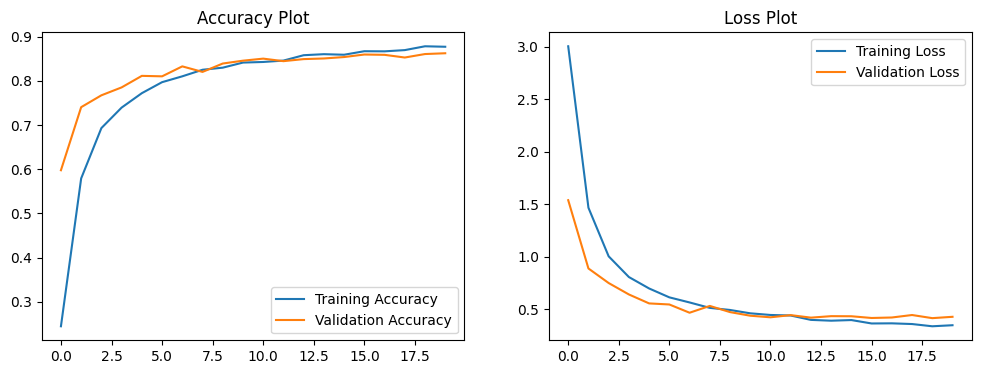

In [6]:

# --- 4C: Plot Training History ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Plot')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Plot')
plt.legend()
plt.show()

In [7]:
# Save the model file with the learned weights
MODEL_FILE_NAME = 'indian_ts_classifier.h5'
model.save(MODEL_FILE_NAME)
print(f"Model saved successfully as {MODEL_FILE_NAME}")

Model saved successfully as indian_ts_classifier.h5


In [8]:
from tensorflow.keras.models import load_model
loaded_model = load_model(MODEL_FILE_NAME)
print("Model reloaded for prediction and evaluation.")

Model reloaded for prediction and evaluation.


In [9]:
# Evaluate model performance on the validation set
loss, accuracy = loaded_model.evaluate(X_val, y_val, verbose=1)

print("\n" + "="*40)
print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy*100:.2f}%")
print("="*40)

88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8590 - loss: 0.4208

Final Validation Loss: 0.4132
Final Validation Accuracy: 86.05%


88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


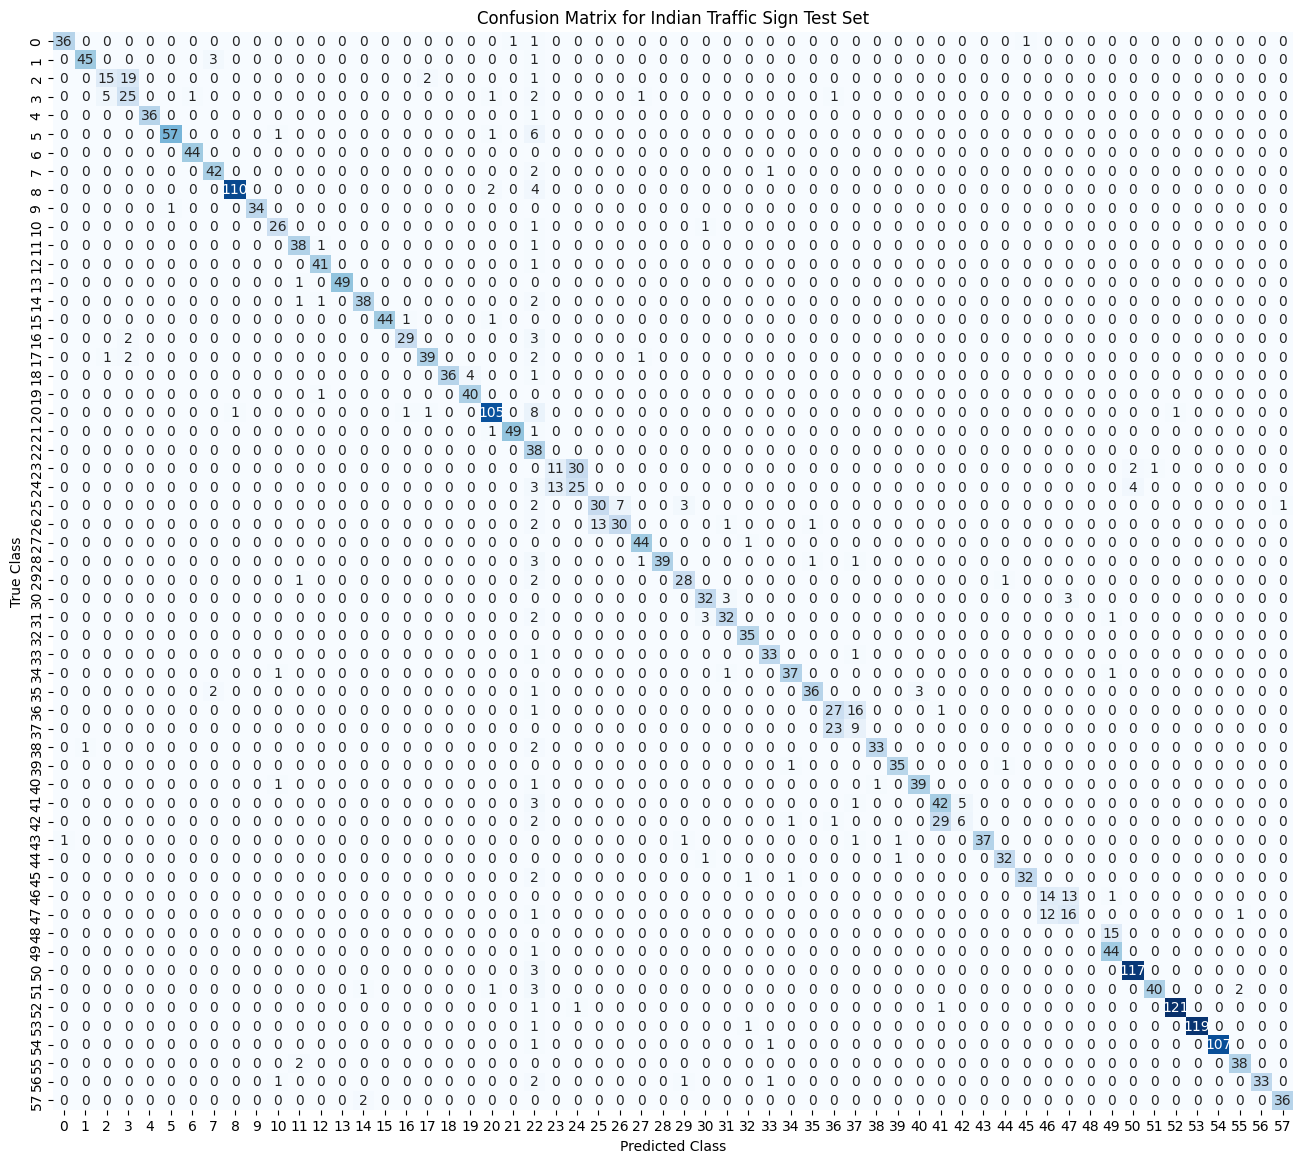

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions
y_pred_probs = loaded_model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Get true classes (convert one-hot y_val back to integers)
y_true_classes = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix for Indian Traffic Sign Test Set')
plt.show()

* This section details a custom step not required for basic classification, but vital for a real-world system.

* We are implementing a Sign-to-Action Mapping to instantly turn the model's numerical output into a driving command.

In [11]:
# --- 1. Load Class Labels from traffic_sign.csv ---
BASE_DIR = '/kaggle/input/indian-traffic-sign-dataset/'
CSV_NESTED_FOLDER = 'Indian-Traffic Sign-Dataset'

sign_names_path = os.path.join(BASE_DIR, CSV_NESTED_FOLDER, 'traffic_sign.csv')

try:
    sign_names_df = pd.read_csv(sign_names_path, sep=',')
except FileNotFoundError:
    # Fallback check for the simple path, just in case
    sign_names_path = os.path.join(BASE_DIR, 'traffic_sign.csv')
    sign_names_df = pd.read_csv(sign_names_path, sep=',')
    
# Map ClassId to the 'Name' column
CLASS_LABELS = sign_names_df.set_index('ClassId')['Name'].to_dict()


# --- 2. DEFINE THE COMPLETE ACTION MAPPING DICTIONARY (Classes 0-58) ---
ACTION_MAPPING = {
    # ------------------ PROHIBITORY/MANDATORY (Classes 0-25) ------------------
    0:  "APPLY BRAKES: YIELD (Give Way)",
    1:  "PROHIBITED: NO ENTRY",
    2:  "DIRECTION: ONE-WAY TRAFFIC",
    3:  "DIRECTION: ONE-WAY TRAFFIC",
    4:  "PROHIBITED: NO VEHICLES (Both Directions)",
    5:  "PROHIBITED: NO ENTRY FOR CYCLES",
    6:  "PROHIBITED: NO ENTRY FOR GOODS VEHICLES",
    7:  "PROHIBITED: NO ENTRY FOR PEDESTRIANS",
    8:  "PROHIBITED: NO ENTRY FOR BULLOCK CARTS",
    9:  "PROHIBITED: NO ENTRY FOR HAND CARTS",
    10: "PROHIBITED: NO ENTRY FOR MOTOR VEHICLES",
    11: "WARNING: HEIGHT LIMIT (Check clearance)",
    12: "WARNING: WEIGHT LIMIT (Check load)",
    13: "WARNING: AXLE WEIGHT LIMIT",
    14: "WARNING: LENGTH LIMIT",
    15: "PROHIBITED: NO LEFT TURN",
    16: "PROHIBITED: NO RIGHT TURN",
    17: "PROHIBITED: NO OVERTAKING",
    18: "REDUCE SPEED: Maximum 90 km/h",
    19: "REDUCE SPEED: Maximum 110 km/h",
    20: "PROHIBITED: HORN PROHIBITED",
    21: "PROHIBITED: NO PARKING",
    22: "PROHIBITED: NO STOPPING",
    23: "WARNING: SPEED BREAKER AHEAD (Reduce speed)",
    24: "WARNING: ROUGH ROAD AHEAD",
    25: "WARNING: MEN AT WORK",
    
    # ------------------ WARNINGS/INFORMATIVE (Classes 26-58) ------------------
    26: "WARNING: LOOSE GRAVEL AHEAD",
    27: "WARNING: FALLING ROCKS AHEAD",
    28: "WARNING: PEDESTRIAN CROSSING AHEAD",
    29: "WARNING: SCHOOL AHEAD (Reduce speed, extreme caution)",
    30: "WARNING: CYCLE CROSSING AHEAD",
    31: "WARNING: CATTLE/WILD ANIMALS AHEAD",
    32: "WARNING: SLIPPERY ROAD",
    33: "WARNING: FERRY AHEAD",
    34: "WARNING: DANGEROUS DIP",
    35: "WARNING: DANGEROUS HUMP",
    36: "WARNING: NARROW ROAD AHEAD",
    37: "WARNING: NARROW BRIDGE AHEAD",
    38: "WARNING: ROAD WIDENS AHEAD",
    39: "WARNING: DANGEROUS CURVE TO THE LEFT",
    40: "WARNING: DANGEROUS CURVE TO THE RIGHT",
    41: "WARNING: HAIRPIN BEND LEFT",
    42: "WARNING: HAIRPIN BEND RIGHT",
    43: "WARNING: ACCIDENT PRONE AREA (General caution)",
    44: "WARNING: STEEP ASCENT",
    45: "WARNING: STEEP DESCENT",
    46: "WARNING: DUAL CARRIAGEWAY ENDS",
    47: "WARNING: DUAL CARRIAGEWAY BEGINS",
    48: "MANDATORY: KEEP LEFT",
    49: "MANDATORY: TURN LEFT",
    50: "MANDATORY: TURN RIGHT",
    51: "MANDATORY: GO STRAIGHT",
    52: "MANDATORY: ROUNDABOUT",
    53: "MANDATORY: SOUND HORN",
    54: "MANDATORY: USE SNOW CHAINS",
    55: "INFORMATIVE: PARKING PROHIBITED",
    56: "INFORMATIVE: PARKING ALLOWED",
    57: "INFORMATIVE: HOSPITAL AHEAD",
    58: "INFORMATIVE: REST AREA", 
}

# --- 3. Prediction-to-Action Function (No changes needed) ---
def get_sign_action(image_array, model_path, action_map, class_map, img_size=30):
    """
    Takes a pre-processed image array, predicts the sign, and returns the action command.
    """
    try:
        model = load_model(model_path)
    except Exception as e:
        return {"Error": f"Model loading error: {e}"}

    # Add batch dimension and predict
    img_input = np.expand_dims(image_array, axis=0)
    prediction_probs = model.predict(img_input, verbose=0)[0]
    
    # Get the predicted class ID and its confidence
    predicted_id = np.argmax(prediction_probs)
    confidence = prediction_probs[predicted_id]
    
    # Lookup the action command
    action_command = action_map.get(predicted_id, "No Action Defined")
    
    return {
        "Predicted_ID": predicted_id,
        "Sign_Name": class_map.get(predicted_id, "Unknown Sign"),
        "Action_Command": action_command,
        "Confidence": f"{confidence * 100:.2f}%"
    }

print("Class Labels, Action Mapping, and Prediction Function are fully defined for 59 classes.")

Class Labels, Action Mapping, and Prediction Function are fully defined for 59 classes.


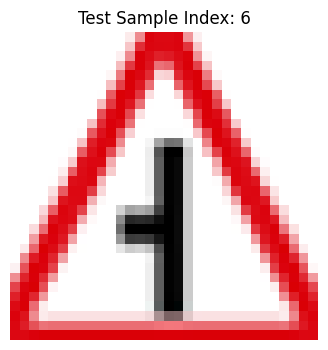


INDIAN TRAFFIC SIGN CLASSIFICATION & ACTION RESULT
 Ground Truth Sign: Side road junction (ID: 37)
--------------------------------------------------
Model Prediction:  Side road junction
Confidence:          61.03%
Predicted ID:        36
--------------------------------------------------
 ACTION COMMAND:    WARNING: NARROW ROAD AHEAD


In [12]:
# --- 1. CHOOSE YOUR TEST INDEX ---
TEST_INDEX_NUMBER = 6
MODEL_NAME = 'indian_ts_classifier.h5'

# Check bounds before proceeding
if TEST_INDEX_NUMBER >= len(X_val):
    raise IndexError(f"Index {TEST_INDEX_NUMBER} is out of bounds for the validation set (size: {len(X_val)}).")

# --- 2. Get the Sample Image and True Label ---
sample_image = X_val[TEST_INDEX_NUMBER]
true_label_one_hot = y_val[TEST_INDEX_NUMBER]
true_id = np.argmax(true_label_one_hot)

# --- 3. Execute the Prediction Function (Requires get_sign_action to be defined) ---
# NOTE: The get_sign_action function must be defined earlier in the notebook.
final_result = get_sign_action(
    image_array=sample_image,
    model_path=MODEL_NAME, 
    action_map=ACTION_MAPPING, 
    class_map=CLASS_LABELS
)

# --- 4. Display Image and Results ---
# Display the image first
plt.figure(figsize=(4, 4))
plt.imshow(sample_image) 
plt.title(f"Test Sample Index: {TEST_INDEX_NUMBER}", fontsize=12)
plt.xlabel(f"True ID {true_id}: {CLASS_LABELS[true_id]}")
plt.axis('off')
plt.show() 

# Print the details below the image
print("\n" + "="*50)
print("INDIAN TRAFFIC SIGN CLASSIFICATION & ACTION RESULT")
print("="*50)

if 'Error' in final_result:
    print(f"[ERROR] Prediction Failed: {final_result['Error']}")
else:
    # Print the Ground Truth for easy comparison
    print(f" Ground Truth Sign: {CLASS_LABELS[true_id]} (ID: {true_id})")
    print("-" * 50)
    
    # Print the model's prediction details
    print(f"Model Prediction:  {final_result['Sign_Name']}")
    print(f"Confidence:          {final_result['Confidence']}")
    print(f"Predicted ID:        {final_result['Predicted_ID']}")
    print("-" * 50)
    
    # Print the Action Command (The final output)
    print(f" ACTION COMMAND:    {final_result['Action_Command']}")
    print("="*50)